In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [2]:
import pandas as pd

df = pd.read_csv('titanic_data_updated.csv')

print(f"Dataset Shape--> \n{df.shape}")
print("-" * 50)

print(f"\nFirst 10 Rows-->")
display(df.head(10))
print("-" * 50)

print(f"\n5 Random Samples-->")
display(df.sample(5))

Dataset Shape--> 
(891, 12)
--------------------------------------------------

First 10 Rows-->


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,no,third,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,no,first,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,no,third,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,yes,third,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,yes,second,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


--------------------------------------------------

5 Random Samples-->


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
407,408,yes,second,"Richards, Master. William Rowe",male,3.0,1,1,29106,18.7500,NaN,S
347,348,yes,third,"Davison, Mrs. Thomas Henry (Mary E Finck)",female,NaN,1,0,386525,16.1000,NaN,S
542,543,no,third,"Andersson, Miss. Sigrid Elisabeth",female,11.0,4,2,347082,31.2750,NaN,S
841,842,no,second,"Mudd, Mr. Thomas Charles",male,16.0,0,0,S.O./P.P. 3,10.5000,NaN,S
879,880,yes,first,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C


In [3]:
from sklearn.model_selection import train_test_split

df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train--> {X_train.shape}")
print(f"Shape of X_test--> {X_test.shape}\n")

print(f"Shape of y_train--> {y_train.shape}")
print(f"Shape of y_test--> {y_test.shape}")


Shape of X_train--> (712, 8)
Shape of X_test--> (179, 8)

Shape of y_train--> (712,)
Shape of y_test--> (179,)


In [4]:
import numpy as np
from sklearn.impute import SimpleImputer



age_imputer = SimpleImputer(missing_values=np.nan,
                            strategy='mean')
age_imputer.fit(X_train[['Age']])
X_train['Age'] = age_imputer.transform(X_train[['Age']]).ravel()
X_test['Age'] = age_imputer.transform(X_test[['Age']]).ravel()



embar_imputer = SimpleImputer(missing_values=np.nan,
                              strategy='most_frequent')
embar_imputer.fit(X_train[['Embarked']])
X_train['Embarked'] = embar_imputer.transform(X_train[['Embarked']]).ravel()
X_test['Embarked'] = embar_imputer.transform(X_test[['Embarked']]).ravel()



cabin_imputer = SimpleImputer(missing_values=np.nan,
                               strategy='constant',
                               fill_value='Missing')
cabin_imputer.fit(X_train[['Cabin']])
X_train['Cabin'] = cabin_imputer.transform(X_train[['Cabin']]).ravel()
X_test['Cabin'] = cabin_imputer.transform(X_test[['Cabin']]).ravel()

print(f"Checking X_train Missing Values-->")
display(X_train.isnull().sum())
print("-" * 40)

print(f"\nChecking X_test Missing Values-->")
display(X_test.isnull().sum())

Checking X_train Missing Values-->


Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Cabin       0
Embarked    0
dtype: int64

----------------------------------------

Checking X_test Missing Values-->


Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Cabin       0
Embarked    0
dtype: int64

# Outlier Detection

### Using Z-Score

In [5]:
mean_of_age = X_train['Age'].mean()
std_of_age = X_train['Age'].std()

X_train['Zscore_age'] = (X_train['Age'] - mean_of_age) / std_of_age

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Zscore_age
331,first,male,45.500000,0,0,28.5000,C124,S,1.231398e+00
733,second,male,23.000000,0,0,13.0000,Missing,S,-5.001304e-01
382,third,male,32.000000,0,0,7.9250,Missing,S,1.924808e-01
704,third,male,26.000000,1,0,7.8542,Missing,S,-2.692600e-01
813,third,female,6.000000,4,2,31.2750,Missing,S,-1.808396e+00
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,-6.540440e-01
270,first,male,29.498846,0,0,31.0000,Missing,S,2.734055e-16
860,third,male,41.000000,2,0,14.1083,Missing,S,8.850920e-01
435,first,female,14.000000,1,2,120.0000,B96 B98,S,-1.192742e+00


In [6]:
outliers_age = X_train[abs(X_train['Zscore_age']) > 3]

print(len(outliers_age))

display(outliers_age)

5


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Zscore_age
116,third,male,70.5,0,0,7.750,Missing,Q,3.155317
745,first,male,70.0,1,1,71.000,B22,S,3.116839
630,first,male,80.0,0,0,30.000,A23,S,3.886407
851,third,male,74.0,0,0,7.775,Missing,S,3.424666
672,second,male,70.0,0,0,10.500,Missing,S,3.116839


In [7]:
mean_of_fare = X_train['Fare'].mean()
std_of_fare = X_train['Fare'].std()

X_train['Zscore_fare'] = (X_train['Fare'] - mean_of_fare) / std_of_fare

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Zscore_age,Zscore_fare
331,first,male,45.500000,0,0,28.5000,C124,S,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,-1.192742e+00,1.682019


In [8]:
outliers_fare = X_train[abs(X_train['Zscore_fare']) > 3]

print(len(outliers_fare))

display(outliers_fare)

17


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Zscore_age,Zscore_fare
118,first,male,24.000000,0,1,247.5208,B58 B60,C,-4.231736e-01,4.135780
716,first,female,38.000000,0,0,227.5250,C45,C,6.542216e-01,3.751020
377,first,male,27.000000,0,2,211.5000,C82,C,-1.923032e-01,3.442666
742,first,female,21.000000,2,2,262.3750,B57 B59 B63 B66,C,-6.540440e-01,4.421605
380,first,female,42.000000,0,0,227.5250,Missing,C,9.620488e-01,3.751020
779,first,female,43.000000,0,1,211.3375,B3,S,1.039006e+00,3.439539
730,first,female,29.000000,0,0,211.3375,B5,S,-3.838960e-02,3.439539
88,first,female,23.000000,3,2,263.0000,C23 C25 C27,S,-5.001304e-01,4.433631
341,first,female,24.000000,3,2,263.0000,C23 C25 C27,S,-4.231736e-01,4.433631
557,first,male,29.498846,0,0,227.5250,Missing,C,2.734055e-16,3.751020


### Using IQR

In [9]:
age_Q1 = X_train['Age'].quantile(0.25)
age_Q3 = X_train['Age'].quantile(0.75)

age_IQR = age_Q3 - age_Q1

age_min = age_Q1 - 1.5 * age_IQR
age_max = age_Q3 + 1.5 * age_IQR

print(age_min, age_max)

2.5 54.5


In [10]:
age_outliers = X_train[(X_train['Age'] < age_min) | (X_train['Age'] > age_max)]

print(len(age_outliers))
display(age_outliers)

54


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Zscore_age,Zscore_fare
326,third,male,61.00,0,0,6.2375,Missing,S,2.424228,-0.507004
483,third,female,63.00,0,0,9.5875,Missing,S,2.578141,-0.442543
7,third,male,2.00,3,1,21.0750,Missing,S,-2.116223,-0.221500
305,first,male,0.92,1,2,151.5500,C22 C26,S,-2.199336,2.289105
829,first,female,62.00,0,0,80.0000,B28,S,2.501185,0.912337
626,second,male,57.00,0,0,12.3500,Missing,Q,2.116401,-0.389387
456,first,male,65.00,0,0,26.5500,E38,S,2.732055,-0.116150
172,third,female,1.00,1,1,11.1333,Missing,S,-2.193180,-0.412799
164,third,male,1.00,4,1,39.6875,Missing,S,-2.193180,0.136642
381,third,female,1.00,0,2,15.7417,Missing,C,-2.193180,-0.324124


In [11]:
fare_Q1 = X_train['Fare'].quantile(0.25)
fare_Q3 = X_train['Fare'].quantile(0.75)

fare_IQR = fare_Q3 - fare_Q1

fare_min = max(0, fare_Q1 - 1.5 * fare_IQR)
fare_max = fare_Q3 + 1.5 * fare_IQR

print(fare_min, fare_max)

0 64.3625


In [12]:
fare_outliers = X_train[(X_train['Fare'] < fare_min) | (X_train['Fare'] > fare_max)]

print(len(fare_outliers))
display(fare_outliers)

96


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Zscore_age,Zscore_fare
118,first,male,24.0,0,1,247.5208,B58 B60,C,-0.423174,4.135780
486,first,female,35.0,1,0,90.0000,C93,S,0.423351,1.104757
716,first,female,38.0,0,0,227.5250,C45,C,0.654222,3.751020
390,first,male,36.0,1,2,120.0000,B96 B98,S,0.500308,1.682019
377,first,male,27.0,0,2,211.5000,C82,C,-0.192303,3.442666
...,...,...,...,...,...,...,...,...,...,...
681,first,male,27.0,0,0,76.7292,D49,C,-0.192303,0.849400
385,second,male,18.0,0,0,73.5000,Missing,S,-0.884914,0.787264
700,first,female,18.0,1,0,227.5250,C62 C64,C,-0.884914,3.751020
435,first,female,14.0,1,2,120.0000,B96 B98,S,-1.192742,1.682019


# Best detector of Outlier and Handling

In [13]:
# Z-Score outlier detection is better for age ouliers

X_train = X_train[abs(X_train['Zscore_age']) <= 3]

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Zscore_age,Zscore_fare
331,first,male,45.500000,0,0,28.5000,C124,S,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,-1.192742e+00,1.682019


In [18]:
X_train['Fare'] = X_train['Fare'].clip(fare_min, fare_max)

X_train['Fare'].max()

C:\Users\User\AppData\Local\Temp\ipykernel_3472\3237031298.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Fare'] = X_train['Fare'].clip(fare_min, fare_max)


64.3625

In [20]:
df = pd.read_csv('marks_dataset.csv')
df

,student_name,maths_marks,science_marks,english_marks,social_studies_marks,language_marks
0,Mr. Gregory Homenick,69,24,52,4,83
1,Marlene Leffler IV,62,59,70,54,52
2,Josephine Ebert,29,76,13,8,19
3,Dr. Irene Green,44,66,14,2,14
4,Jake Huel,49,23,63,86,68
...,...,...,...,...,...,...
95,Renee Schinner,69,99,73,62,32
96,Marguerite Ebert,32,62,82,99,42
97,Jorge Bednar,77,56,46,79,25
98,Mrs. Roxanne Jacobi,54,66,70,49,20


# Winsorization Technique Code

<Axes: xlabel='maths_marks', ylabel='Density'>

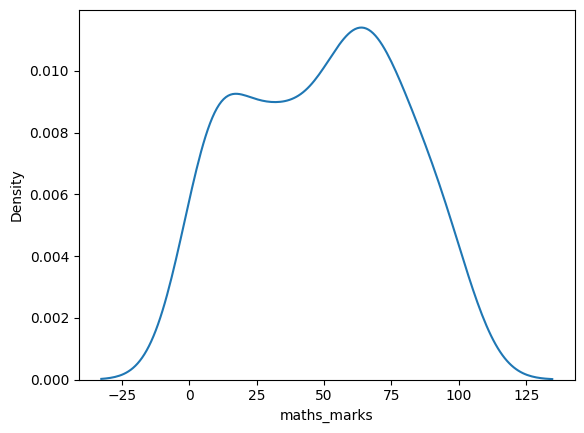

In [22]:
sns.kdeplot(data = df,
            x = 'maths_marks')

<Axes: xlabel='maths_marks'>

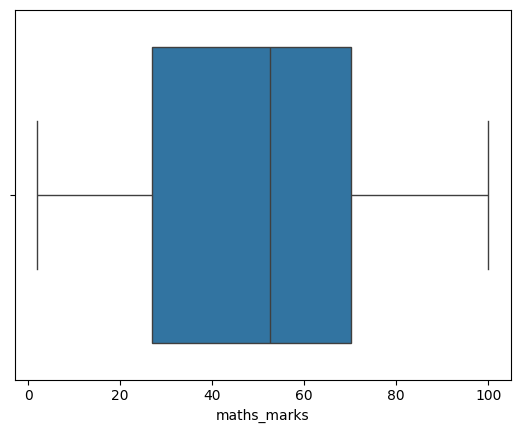

In [23]:
sns.boxplot(data = df,
            x = 'maths_marks')

In [25]:
df['maths_marks'].describe()

count    100.000000
mean      48.950000
std       28.999956
min        2.000000
25%       27.000000
50%       52.500000
75%       70.250000
max      100.000000
Name: maths_marks, dtype: float64

In [27]:
x = 12
x = x/100

min_range = df['maths_marks'].quantile(x)
max_range = df['maths_marks'].quantile(1-x)

print(f"Min range--> {min_range} \nMax range--> {max_range}")

Min range--> 9.879999999999999 
Max range--> 85.36000000000001
